# Plot Neutron $G_E^n$ and $G_M^n$ Fitting Results 
Plot neutron form factor vs. Q^2max for fits  with stat errors.

In [1]:
##Import and Definition
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

Lambda2 = 0.71
GE0 = 0.0
GM0 = -1.91304272
bnd = '5'

## $G_E^n$

### Load $G_E^n$ Fitting Results

In [4]:
## General GEn parameters
Q2plot = 1001.0
kmax = 10
Q2str = '1000' # <4 for GEn, <10 for GMn

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=16)

In [5]:
##Load Neutron-GEn Sum-Rules Results{{{
##################################################
filename='neutron_GEn_baseline.dat'

# Extract results from text file for non-sum rule fits.
Q2e_sr = []
Ze_sr = []
GE_fit_sr = []
GE_pos_sr = []
GE_neg_sr = []
GErat_fit_sr = []
GErat_pos_sr = []
GErat_neg_sr = []
GED_sr=[]

redchi2_GE_sr=0.0
chi2_GE_sr=0.0
rad_GE_sr=0.0
drad_GE_sr = 0.0
ndof_GE_sr = 0
chi2_Ng_GE_sr=0.0
chi2_gn_GE_sr=0.0
nmax_GE_sr = 0

fitlines2 = open(filename, 'r').readlines()
for i in range(1,2001):
    values = fitlines2[i].split()
    values = np.array(values, dtype=float)
    if values[0] > Q2plot:
        break
    Q2e_sr.append(values[0])
    Ze_sr.append(values[1])
    Gdip = 1./(1.+values[0]/0.71)**2
    GED_sr.append(Gdip)
    GE_fit_sr.append(values[2])
    GE_pos_sr.append((values[2]+abs(values[3])))
    GE_neg_sr.append((values[2]-abs(values[3])))
    GErat_fit_sr.append(values[2]/Gdip)
    GErat_pos_sr.append((values[2]+abs(values[3]))/Gdip)
    GErat_neg_sr.append((values[2]-abs(values[3]))/Gdip)

[Q2max_gen_sr, tcut_gen_sr, t0_gen_sr] = [float(fitlines2[2006].split()[i]) for i in range(0,3)]
    
values = fitlines2[2008].split()
redchi2_GE_sr=float(values[0])
chi2_GE_sr=float(values[1])
chi2_Ng_GE_sr=float(values[2])
chi2_gn_GE_sr=float(values[3])

rad_GE_sr=float(values[4])
drad_GE_sr = float(values[5])
ndof_GE_sr = float(values[6])
nmax_GE_sr = float(values[7])
namGN_GE_sr = float(values[8])
kGN_GE_sr = float(values[9])

drad_GE_sr = abs(drad_GE_sr)
tot_chi2_GE_sr = chi2_GE_sr+chi2_gn_GE_sr
#ndof_GE_sr -= nmax_GE_sr

Q2e_sr = np.array(Q2e_sr, dtype=float)
Ze_sr = np.array(Ze_sr, dtype=float)
GE_fit_sr = np.array(GE_fit_sr, dtype=float)
GE_pos_sr = np.array(GE_pos_sr, dtype=float)
GE_neg_sr = np.array(GE_neg_sr, dtype=float)
GErat_fit_sr = np.array(GErat_fit_sr, dtype=float)
GErat_pos_sr = np.array(GErat_pos_sr, dtype=float)
GErat_neg_sr = np.array(GErat_neg_sr, dtype=float)
GED_sr = np.array(GED_sr, dtype=float)
#}}}

if os.path.isfile(filename):
    print 'file exist', filename
else:
    rad_GE_sr = 0.0
    drad_GE_sr = 0.0

file exist neutron_GEn_baseline.dat


### Load $G_E^n$ Data Points

In [9]:
## Load GEn Data
#########################{{{
def loadGEn(Q2_max, t0, tcut):
    Q2n=[]
    Zn=[]
    GEn=[]
    dGEn=[]
    GEn_rat=[]
    dGEn_rat=[]
        
    fitlines = open('./data/neutron/GLOBFIT17_gen_feb07.out', 'r').readlines()
    for i in range(1,len(fitlines)):
        values = fitlines[i].split()
        values = np.array(values, dtype=float)
        try:#eliminates descriptions in 1st line of file
            Q2test=values[0]
        except:
            continue

        if Q2test>Q2_max:
            continue

        Q2n.append(values[0])
        Gdip = 1./(1.+values[0]/0.71)**2
        GEn.append(values[1])
        dGEn.append(values[2])
        GEn_rat.append(values[1]/Gdip)
        dGEn_rat.append(values[2]/Gdip)

        Q2 = float(values[0])
        z = (sqrt(1+Q2/tcut) - sqrt(1-t0/tcut))/(sqrt(1+Q2/tcut) + sqrt(1-t0/tcut))
        Zn.append(z)

    return Q2n,z, GEn, dGEn,GEn_rat,dGEn_rat
#######################
##Read GE/GD, GM/nuGD, and GE/GM from John's 2007 paper
Q2e_data_sr, Ze_data_sr, GE_data_sr, dGE_data_sr,GErat_data_sr,dGErat_data_sr =loadGEn(Q2plot, t0_gen_sr, tcut_gen_sr)


Q2e_data_sr=np.array(Q2e_data_sr, dtype=float)
Ze_data_sr=np.array(Ze_data_sr, dtype=float)
GE_data_sr=np.array(GE_data_sr, dtype=float)
dGE_data_sr=np.array(dGE_data_sr, dtype=float)
GErat_data_sr=np.array(GErat_data_sr, dtype=float)
dGErat_data_sr=np.array(dGErat_data_sr, dtype=float)
#}}}

In [10]:
## Load fake GEn Data
fitlines = open('./data/neutron/neut_GEn_fakeHQ.dat', 'r').readlines()
Q2E_fake = np.zeros(10, dtype=float)
GEn_fake = np.zeros(10,dtype=float)
dGEn_fake = np.zeros(10,dtype=float)
GEn_rat_fake = np.zeros(10,dtype=float)
dGEn_rat_fake = np.zeros(10,dtype=float)
for i in range(0, len(fitlines)):
    values = fitlines[i].split()
    values = np.array(values, dtype=float)
   
    Q2E_fake[i] = values[0]
    GEn_fake[i] = values[1]
    dGEn_fake[i] = values[2]
    Gdip = 1./(1.+values[0]/0.71)**2
    GEn_rat_fake[i]=(values[1]/Gdip)
    dGEn_rat_fake[i]=(values[2]/Gdip)

### Plot $G_E^n$

In [11]:
## Plotting Range
ymin_GE = -0.3 #np.minimum(np.amin(GM_fit_sr),np.amin(GM_fit))*0.75
ymax_GE = 1.
xmax_GE = 10.
xmin_GE = 0.004

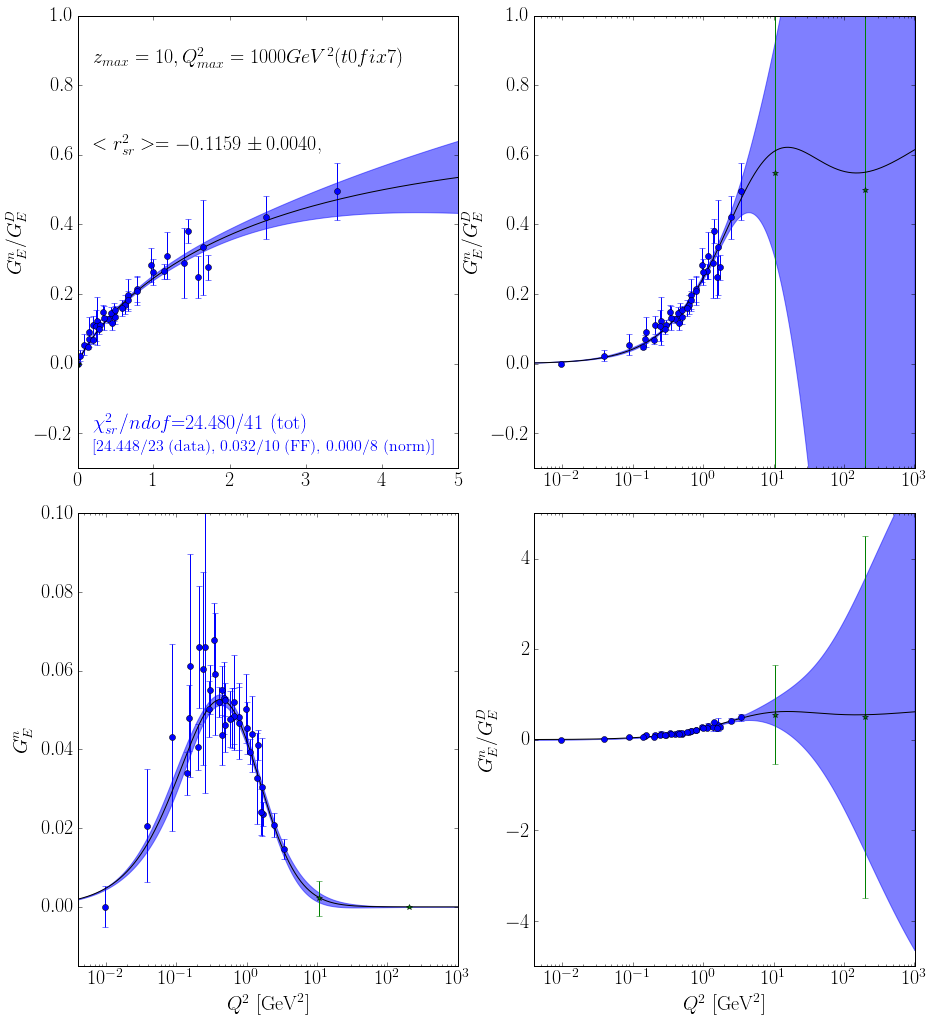

In [60]:
## Plot GEn##########{{{
f1, ax = plt.subplots(2, 2, sharex=False, figsize=(15,15))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GErat
axGE1=ax[0,0]
axGE1.plot(Q2e_sr, GErat_fit_sr, 'k-', color='black',  label='GEfit')
axGE1.fill_between(Q2e_sr, GErat_neg_sr, GErat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGE1.errorbar(Q2e_data, GErat_data, yerr=dGErat_data, fmt='o')
axGE1.errorbar(Q2E_fake, GEn_fake, yerr=dGEn_fake, fmt='*', color='g')

axGE1.set_xlim(xmin_GE, 5)
axGE1.set_ylabel('$G_E^n/G_E^D$') # label, y-axis
axGE1.set_ylim(ymin_GE, ymax_GE)
#axGE1.yaxis.set_major_locator(MultipleLocator((ymax_GE-ymin_GE)/5.0))
#axGE1.yaxis.set_minor_locator(MultipleLocator((ymax_GE-ymin_GE)/10.0))

#######  Subplot for GE.
axGE2=ax[1,0]
#axGE2.plot(Q2e, GE_fit, 'k--', color='black',  label='GEfit')
#axGE2.fill_between(Q2e, GE_neg, GE_pos, edgecolor='red',facecolor='red',alpha=0.5)

#axGE2.plot(Q2e_sr, GE_fit_sr, 'k-', color='black',  label='GEfit')
#axGE2.fill_between(Q2e_sr, GE_neg_sr, GE_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

#axGE2.errorbar(Q2e_data, GE_data, yerr=dGE_data, fmt='o')

#axGE2.set_xlim(xmin_GE, 5)
#axGE2.set_ylabel('$G_E^n$') # label, y-axis
#axGE2.set_ylim(-0.015, 0.1)

#######  x-axis labelling, etc.
#axGE2.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

#######  Subplot for GErat
axGE3=ax[0,1]
#axGE3.plot(Q2e, GErat_fit, 'k--', color='black',  label='GEfit')
#axGE3.fill_between(Q2e, GErat_neg, GErat_pos, edgecolor='red',facecolor='red',alpha=0.5)

axGE3.plot(Q2e_sr, GErat_fit_sr, 'k-', color='black',  label='GEfit')
axGE3.fill_between(Q2e_sr, GErat_neg_sr, GErat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGE3.errorbar(Q2e_data, GErat_data, yerr=dGErat_data, fmt='o')
axGE3.errorbar(Q2E_fake, GEn_rat_fake, yerr=dGEn_rat_fake, fmt='*', color='g')

axGE3.set_xscale('log')
axGE3.set_xlim(xmin_GE, 1005.)
axGE3.set_ylabel('$G_E^n/G_E^D$') # label, y-axis
axGE3.set_ylim(ymin_GE, ymax_GE)

#######  Subplot for GE.
axGE4=ax[1,0]
#axGE4.plot(Q2e, GE_fit, 'k--', color='black',  label='GEfit')
#axGE4.fill_between(Q2e, GE_neg, GE_pos, edgecolor='red',facecolor='red',alpha=0.5)

axGE4.plot(Q2e_sr, GE_fit_sr, 'k-', color='black',  label='GEfit')
axGE4.fill_between(Q2e_sr, GE_neg_sr, GE_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGE4.errorbar(Q2e_data, GE_data, yerr=dGE_data, fmt='o')
axGE4.errorbar(Q2E_fake, GEn_fake, yerr=dGEn_fake, fmt='*', color='g')

axGE4.set_xscale('log')
axGE4.set_xlim(xmin_GE, 1005.)
axGE4.set_ylabel('$G_E^n$') # label, y-axis
axGE4.set_ylim(-0.015, 0.1)

#######  Subplot for GE.
######  Subplot for GErat
axGE31=ax[1,1]
#axGE31.plot(Q2e, GErat_fit, 'k--', color='black',  label='GEfit')
#axGE31.fill_between(Q2e, GErat_neg, GErat_pos, edgecolor='red',facecolor='red',alpha=0.5)

axGE31.plot(Q2e_sr, GErat_fit_sr, 'k-', color='black',  label='GEfit')
axGE31.fill_between(Q2e_sr, GErat_neg_sr, GErat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGE31.errorbar(Q2e_data, GErat_data, yerr=dGErat_data, fmt='o')
axGE31.errorbar(Q2E_fake, GEn_rat_fake, yerr=dGEn_rat_fake, fmt='*', color='g')

axGE31.set_xscale('log')
axGE31.set_xlim(xmin_GE, 1005.)
axGE31.set_ylabel('$G_E^n/G_E^D$') # label, y-axis
axGE31.set_ylim(-5.0, 5.0)
axGE31.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis


#######  x-axis labelling, etc.
axGE2.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

#######  x-axis labelling, etc.
axGE4.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

axGE1.text(0.2, 0.85, r'$z_{max}=%d, Q^2_{max}=%s GeV^2 (%s)$'%(kmax,Q2str,t0mod))
#axGE1.text(0.2, 0.7, r'$<r^{2}_{ls}>=%5.4f\pm %5.4f$'%(rad_GE,drad_GE))
axGE1.text(0.2, 0.6, r'$<r^{2}_{sr}>=%5.4f\pm %5.4f$,'%( rad_GE_sr, drad_GE_sr))

#axGE1.text(0.201, -0.05, r'$\chi^{2}_{ls}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GE, ndof_GE), color='red')
#axGE1.text(0.201, -0.10, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
#         %(chi2_GE, ndof_GE-nmax_GE-kGN_GE, chi2_gn_GE, nmax_GE,chi2_Ng_GE, kGN_GE ), 
#          fontproperties=font_prop, color='red')

axGE1.text(0.201, -0.20, r'$\chi^{2}_{sr}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GE_sr, ndof_GE_sr), color='blue')
axGE1.text(0.201, -0.25, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
         %(chi2_GE_sr, ndof_GE_sr-nmax_GE_sr-kGN_GE_sr, chi2_gn_GE_sr, nmax_GE_sr,chi2_Ng_GE_sr, kGN_GE_sr ), 
          fontproperties=font_prop, color='blue')

# plt.show()
plotname=filename.replace('.dat','_new.pdf')
plt.savefig(plotname,bbox_inches='tight')
#plotname=plotname.replace('.png','.pdf')

plt.savefig('GEn_baseline_kmax10.pdf',bbox_inches='tight')
plt.savefig('GEn_baseline_kmax10.png',bbox_inches='tight')

#plt.savefig(plotname)
#}}}

## $G_M^n$

### Load $G_M^n$ Fitting Results

In [61]:
##General GMn parameters .
Q2plot = 1001
Q2str = '1000' # <4 for GEn, <10 for GMn

#kmax = 16
mod = 'GMn'
#t0mod = 't0zero'
#t0mod = 't0opt'
#folder = 'neut_'+fitdata+'_FF/z'+str(kmax) # folder containing central fits
folder = './z'+str(kmax) # folder containing central fits

In [35]:
##Load Neutron-GMn Sum-Rules Results{{{
##################################################
filename='neutron_GMn_baseline.dat'

# Extract results from text file for non-sum rule fits.
Q2m_sr = []
Zm_sr = []
GM_fit_sr = []
GM_pos_sr = []
GM_neg_sr = []
GMrat_fit_sr = []
GMrat_pos_sr = []
GMrat_neg_sr = []
GMD_sr=[]

redchi2_GM_sr=0.0
chi2_GM_sr=0.0
rad_GM_sr=0.0
drad_GM_sr = 0.0
ndof_GM_sr = 0
chi2_Ng_GM_sr=0.0
chi2_gn_GM_sr=0.0
nmax_GM_sr = 0

fitlines2 = open(filename, 'r').readlines()
for i in range(1,2001):
    values = fitlines2[i].split()
    values = np.array(values, dtype=float)
    if values[0] > Q2plot:
        break
    Q2m_sr.append(values[0])
    Zm_sr.append(values[1])
    Gdip = 1./(1.+values[0]/0.71)**2
    GMD_sr.append(GM0*Gdip)
    GM_fit_sr.append(values[2])
    GM_pos_sr.append((values[2]+abs(values[3])))
    GM_neg_sr.append((values[2]-abs(values[3])))
    GMrat_fit_sr.append(values[2]/GM0/Gdip)
    GMrat_pos_sr.append((values[2]+abs(values[3]))/GM0/Gdip)
    GMrat_neg_sr.append((values[2]-abs(values[3]))/GM0/Gdip)

[Q2max_gmn_sr, tcut_gmn_sr, t0_gmn_sr] = [float(fitlines2[2006].split()[i]) for i in range(0,3)]
    
values = fitlines2[2008].split()
redchi2_GM_sr=float(values[0])
chi2_GM_sr=float(values[1])
chi2_Ng_GM_sr=float(values[2])
chi2_gn_GM_sr=float(values[3])

rad_GM_sr=sqrt(float(values[4]))
drad_GM_sr = float(values[5])
ndof_GM_sr = float(values[6])
nmax_GM_sr = float(values[7])
namGN_GM_sr = float(values[8])
kGN_GM_sr = float(values[9])

drad_GM_sr = sqrt(abs(drad_GM_sr))
tot_chi2_GM_sr = chi2_GM_sr+chi2_gn_GM_sr
#ndof_GM_sr -= nmax_GM_sr

Q2e_sr = np.array(Q2e_sr, dtype=float)
Ze_sr = np.array(Ze_sr, dtype=float)
GM_fit_sr = np.array(GM_fit_sr, dtype=float)
GM_pos_sr = np.array(GM_pos_sr, dtype=float)
GM_neg_sr = np.array(GM_neg_sr, dtype=float)
GMrat_fit_sr = np.array(GMrat_fit_sr, dtype=float)
GMrat_pos_sr = np.array(GMrat_pos_sr, dtype=float)
GMrat_neg_sr = np.array(GMrat_neg_sr, dtype=float)
GMD_sr = np.array(GMD_sr, dtype=float)
#}}}

if os.path.isfile(filename):
    print 'file exist', filename
else:
    rad_GM_sr = 0.0
    drad_GM_sr = 0.0

file exist neutron_GMn_baseline.dat


### Load $G_M^n$ Data Points


In [36]:
## Load GMn Data
#########################{{{
def loadGMn(Q2_max, t0, tcut):
    Q2n=[]
    Zn=[]
    GMn=[]
    dGMn=[]
    GMn_rat=[]
    dGMn_rat=[]
        
    fitlines = open('./data/neutron/GLOBFIT17_gmn_feb07.out', 'r').readlines()
    #fitlines = open('../data/NEWFIT_gmn_2012.out', 'r').readlines()
    for i in range(1,len(fitlines)):
        values = fitlines[i].split()
        values = np.array(values, dtype=float)
        try:#eliminates descriptions in 1st line of file
            Q2test=float(values[0])
        except:
            continue

        if Q2test>Q2_max:
            continue
        Q2n.append(values[0])
        Gdip = 1./(1.+values[0]/0.71)**2
        GMn_rat.append(values[1])
        dGMn_rat.append(values[2])
        GMn.append(values[1]*GM0*Gdip)
        dGMn.append(values[2]*GM0*Gdip)
    
        Q2 = float(values[0])
        z = (sqrt(1+Q2/tcut) - sqrt(1-t0/tcut))/(sqrt(1+Q2/tcut) + sqrt(1-t0/tcut))
        Zn.append(z)
    
    return Q2n,z,GMn, dGMn, GMn_rat, dGMn_rat
#######################
Q2m_data_sr, Zm_data_sr, GM_data_sr, dGM_data_sr, GMrat_data_sr, dGMrat_data_sr=loadGMn(Q2plot, t0_gmn_sr, tcut_gmn_sr)


Q2m_data_sr=np.array(Q2m_data_sr, dtype=float)
Zm_data_sr=np.array(Zm_data_sr, dtype=float)
GM_data_sr=np.array(GM_data_sr, dtype=float)
dGM_data_sr=np.array(dGM_data_sr, dtype=float)
GMrat_data_sr=np.array(GMrat_data_sr, dtype=float)
dGMrat_data_sr=np.array(dGMrat_data_sr, dtype=float)
#for i in range(len(Q2m_data)):
#    print '---', Q2m_data[i], GM_data[i]
#}}}

In [37]:
## Load fake GEn Data
fitlines = open('./data/neutron/neut_GMn_fakeHQ.dat', 'r').readlines()
Q2M_fake = np.zeros(10, dtype=float)
GMn_fake = np.zeros(10,dtype=float)
dGMn_fake = np.zeros(10,dtype=float)
GMn_rat_fake = np.zeros(10,dtype=float)
dGMn_rat_fake = np.zeros(10,dtype=float)

for i in range(0, len(fitlines)):
    values = fitlines[i].split()
    values = np.array(values, dtype=float)
   
    Q2M_fake[i] = values[0]
    GMn_fake[i] = values[1]
    dGMn_fake[i] = values[2]
    Gdip = 1./(1.+values[0]/0.71)**2
    GMn_rat_fake[i]=(values[1]/Gdip/GM0)
    dGMn_rat_fake[i]=(values[2]/Gdip/GM0)

### Plot $G_M^n/G_D$ vs. $Q^2$

In [38]:
##Plotting Ranges
ymin_GM = 0.4 #np.minimum(np.amin(GM_fit_sr),np.amin(GM_fit))*0.75
ymax_GM = 1.20
xmax_GM = 11.2

ymin_GM1 = -1.20 #np.minimum(np.amin(GM_fit_sr),np.amin(GM_fit))*0.75
ymax_GM1 = 0.1
xmax_GM1 = 11.2

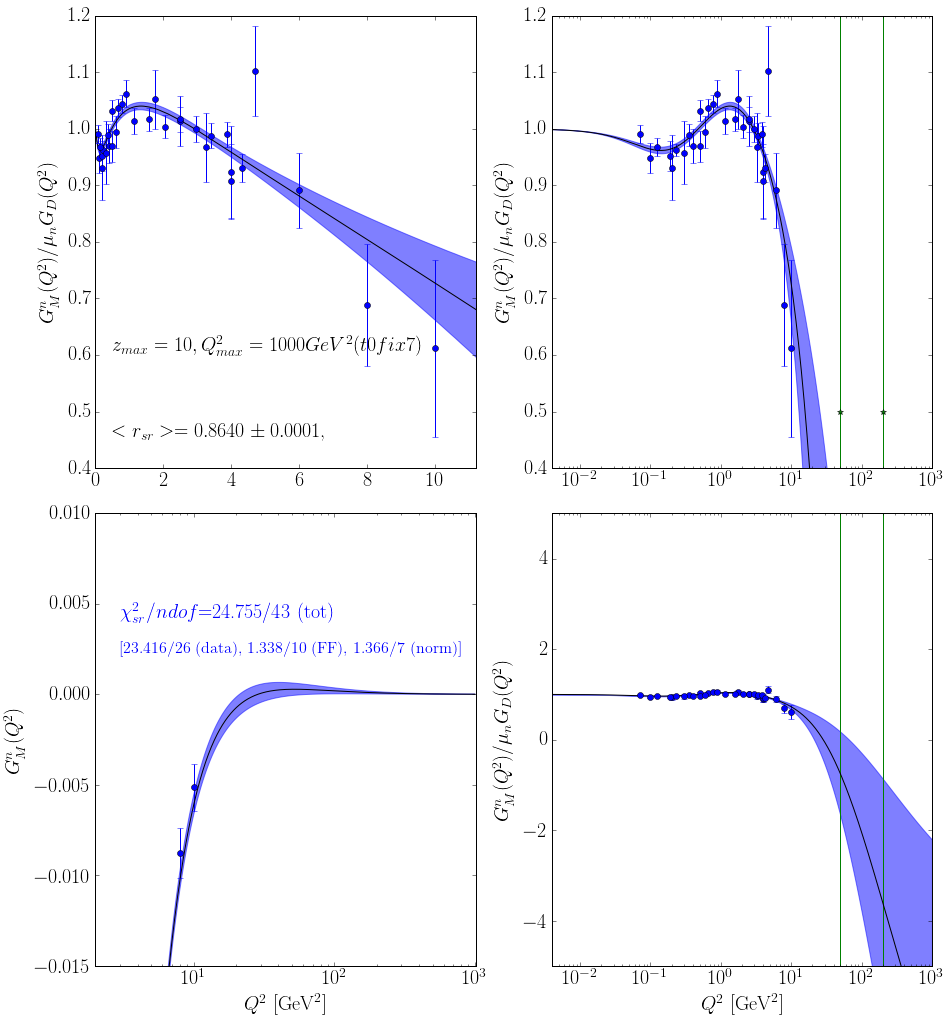

In [39]:
## Plot GMn in log scale##########{{{
f2, ax = plt.subplots(2, 2, sharex=False, figsize=(15,15))
f2.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GM/GD.
axGM1 = ax[0,0]
#axGM1.plot(Q2m, GMrat_fit, 'k--', color='black',  label='GMfit')
#axGM1.fill_between(Q2m, GMrat_neg, GMrat_pos, edgecolor='red',facecolor='red',alpha=0.5)

axGM1.plot(Q2m_sr, GMrat_fit_sr, 'k-', color='black',  label='GMfit')
axGM1.fill_between(Q2m_sr, GMrat_neg_sr, GMrat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGM1.errorbar(Q2m_data_sr, GMrat_data_sr, yerr=dGMrat_data_sr, fmt='o')
axGM1.errorbar(Q2M_fake, GMn_rat_fake, yerr=dGMn_rat_fake, fmt='*', color='g')

axGM1.set_xlim(4e-4, xmax_GM)
axGM1.set_ylabel('$G_M^n(Q^2)/\mu_n G_D(Q^2)$') # label, y-axis
axGM1.set_ylim(ymin_GM, ymax_GM)

#######  Subplot for GM.
axGM2 = ax[1,0]
#axGM2.plot(Q2m, GM_fit, 'k--', color='black',  label='GMfit')
#axGM2.fill_between(Q2m, GM_neg, GM_pos, edgecolor='red',facecolor='red',alpha=0.5)

#axGM2.plot(Q2m_sr, GM_fit_sr, 'k-', color='black',  label='GMfit')
#axGM2.fill_between(Q2m_sr, GM_neg_sr, GM_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

#axGM2.errorbar(Q2m_data, GM_data, yerr=dGM_data, fmt='o')

#axGM2.set_xlim(4e-4, xmax_GM1)
#axGM2.set_ylabel('$G_M^n(Q^2)$') # label, y-axis
#axGM2.set_ylim(-2.0, ymax_GM1)

#######  x-axis labelling, etc.
#plt.setp(axGM2.get_xticklabels(), visible=False)
axGM2.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis

#######  Subplot for GM/GD.
axGM3 = ax[0,1]
#axGM3.plot(Q2m, GMrat_fit, 'k--', color='black',  label='GMfit')
#axGM3.fill_between(Q2m, GMrat_neg, GMrat_pos, edgecolor='red',facecolor='red',alpha=0.5)

axGM3.plot(Q2m_sr, GMrat_fit_sr, 'k-', color='black',  label='GMfit')
axGM3.fill_between(Q2m_sr, GMrat_neg_sr, GMrat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGM3.errorbar(Q2m_data_sr, GMrat_data_sr, yerr=dGMrat_data_sr, fmt='o')
axGM3.errorbar(Q2M_fake, GMn_rat_fake, yerr=dGMn_rat_fake, fmt='*', color='g')

axGM3.set_xscale('log')
axGM3.set_xlim(4e-3, 1015.)
axGM3.set_ylabel('$G_M^n(Q^2)/\mu_n G_D(Q^2)$') # label, y-axis
axGM3.set_ylim(ymin_GM, ymax_GM)

#######  Subplot for GM.
#axGM4 = ax[1,1]
axGM4 = ax[1,0]
#axGM4.plot(Q2m, GM_fit, 'k--', color='black',  label='GMfit')
#axGM4.fill_between(Q2m, GM_neg, GM_pos, edgecolor='red',facecolor='red',alpha=0.5)

axGM4.plot(Q2m_sr, GM_fit_sr, 'k-', color='black',  label='GMfit')
axGM4.fill_between(Q2m_sr, GM_neg_sr, GM_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGM4.errorbar(Q2m_data_sr, GM_data_sr, yerr=dGM_data_sr, fmt='o')
axGM3.errorbar(Q2M_fake, GMn_fake, yerr=dGMn_fake, fmt='*', color='g')

axGM4.set_xscale('log')
axGM4.set_xlim(2, 1015.)
axGM4.set_ylabel('$G_M^n(Q^2)$') # label, y-axis
axGM4.set_ylim(-0.015, 0.01)

#######  x-axis labelling, etc.
#plt.setp(axGM4.get_xticklabels(), visible=False)
axGM4.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis


#######  Subplot for GM/GD.
axGM31 = ax[1,1]
#axGM31.plot(Q2m, GMrat_fit, 'k--', color='black',  label='GMfit')
#axGM31.fill_between(Q2m, GMrat_neg, GMrat_pos, edgecolor='red',facecolor='red',alpha=0.5)

axGM31.plot(Q2m_sr, GMrat_fit_sr, 'k-', color='black',  label='GMfit')
axGM31.fill_between(Q2m_sr, GMrat_neg_sr, GMrat_pos_sr, edgecolor='blue',facecolor='blue',alpha=0.5)

axGM31.errorbar(Q2m_data_sr, GMrat_data_sr, yerr=dGMrat_data_sr, fmt='o')
axGM31.errorbar(Q2M_fake, GMn_rat_fake, yerr=dGMn_rat_fake, fmt='*', color='g')

axGM31.set_xscale('log')
axGM31.set_xlim(4e-3, 1015.)
axGM31.set_ylabel('$G_M^n(Q^2)/\mu_n G_D(Q^2)$') # label, y-axis
axGM31.set_ylim(-5., 5.)
axGM31.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$') # label, x-axis


axGM1.text(0.5, 0.6, r'$z_{max}=%d, Q^2_{max}=%s GeV^2 (%s)$'%(kmax,Q2str, 't0fix7'))
#axGM1.text(0.5, 0.5, r'$<r^{2}_{ls}>=%5.4f\pm %5.4f$,'%(rad_GM, drad_GM))
axGM1.text(0.5, 0.45, r'$<r_{sr}>=%5.4f\pm %5.4f$,'%(rad_GM_sr, drad_GM_sr))

#axGM2.text(3.001, 0.008, r'$\chi^{2}_{ls}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GM, ndof_GM), color='red')
#axGM2.text(3.0005,0.0063, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
#         %(chi2_GM, ndof_GM-nmax_GM-kGN_GM, chi2_gn_GM, nmax_GM,chi2_Ng_GM, kGN_GM), 
#          fontproperties=font_prop, color='red')

axGM2.text(3.001, 0.004, r'$\chi^{2}_{sr}/ndof$=%5.3f/%d (tot)'%(tot_chi2_GM_sr, ndof_GM_sr), color='blue')
axGM2.text(3.0005,0.0023, r'[%5.3f/%d (data), %5.3f/%d (FF), %5.3f/%d (norm)]'
         %(chi2_GM_sr, ndof_GM_sr-nmax_GM_sr-kGN_GM_sr, chi2_gn_GM_sr, nmax_GM_sr,chi2_Ng_GM_sr, kGN_GM_sr ), 
          fontproperties=font_prop, color='blue')


# plt.show()
#plotname=filename.replace('.dat','_new.pdf')
plt.savefig('GMn_baseline_kmax10.pdf',bbox_inches='tight')
plt.savefig('GMn_baseline_kmax10.png',bbox_inches='tight')
#plotname=plotname.replace('.png','.pdf')
#plt.savefig(plotname)
#}}}